# Дополнительный сигнал о движении валюты

Цель ноутбука — проверить отдельную продуктовую гипотезу: между редкими основными уведомлениями о благоприятном моменте можно сообщать клиенту о **заметном укреплении рубля или валюты получателя**, чтобы дать честный повод открыть приложение и проверить сумму к получению.

| | Основное уведомление | Дополнительное уведомление из этого ноутбука |
|---|---|---|
| Что сообщает | Сейчас статистически благоприятный момент | За последнее время произошло заметное движение |
| Что проверяем без клиентских данных | Долю удачных дат и преимущество над случайным выбором | Заметность, правдивость, частоту, устойчивость и пересечение с основным сигналом |
| Что доказывает пользу | Удачный момент по целевой отметке | Только эксперимент по входам и расчётам перевода |
| Главный показатель запуска | Преимущество над случайным выбором | Дополнительная недельная доля клиентов, проверивших сумму перевода |

Главный принцип текста: **описываем уже случившийся факт**, но не называем его выгодой и не даём обещаний о будущем.

## 1. Что подсказал внешний обзор

У сервисов переводов распространены два вида валютных уведомлений: пользователь сам задаёт желаемый курс или подписывается на регулярное обновление. [Wise](https://wise.com/help/articles/2932395/whats-the-mid-market-exchange-rate) предлагает ежедневные сообщения и уведомление при достижении заданного уровня; [XE](https://help.xe.com/hc/en-gb/articles/360019612078-Xe-Rate-Alerts) и [Western Union](https://www.westernunion.com/gb/en/frequently-asked-questions/faq-exchange-rate-alert.html) также предлагают заданный пользователем уровень.

В нашем наборе нет пользовательских настроек, расчётов, переводов или иной личной истории. Поэтому механики «ваш желаемый курс» и «с вашей последней проверки» здесь **неприменимы**. Их нельзя имитировать общей датой или средним размером перевода — это создало бы выдуманную персонализацию.

Из внешнего опыта берём только три общих ограничения:

- информационный ориентир нельзя выдавать за доступное клиенту предложение: Банк России указывает, что официальный курс устанавливается [без обязательства покупать или продавать валюту по нему](https://www.cbr.ru/currency_base/), а XE отдельно предлагает проверять фактический курс отправки;
- сообщение должно приходить по событию, а не ежедневно: простые уведомления «по необходимости» показали эффект в финансовом полевом эксперименте ([Management Science](https://pubsonline.informs.org/doi/abs/10.1287/mnsc.2022.00304));
- краткосрочный рост открытий ещё не означает устойчивой пользы: ежедневная рассылка в микрорандомизированном эксперименте повышала ближайшие открытия, но не продлевала общую вовлечённость ([результаты исследования](https://pmc.ncbi.nlm.nih.gov/articles/PMC10337295/)).

Отсюда наша ниша: **автоматически находить редкие и объяснимые изменения в обезличенном валютном ряду**, честно называть уже произошедшее движение и вести клиента проверять актуальные условия. Внешние источники не доказывают наши правила — они помогают не превратить их в торговый совет или ежедневный шум.

## 2. Данные и смысл курса

Используется `data/features/fx_features_daily.parquet` — тот же набор признаков, который разобран в основном исследовательском ноутбуке и документации.

- `rate` — рублей за одну единицу валюты получателя.
- `ret_5 < 0` — валюта получателя стала дешевле в рублях, то есть рубль укрепился относительно неё.
- `ret_5 > 0` — валюта получателя укрепилась относительно рубля.
- Пять наблюдений — пять официальных обновлений, а не всегда ровно пять календарных дней. Поэтому в сообщении безопаснее указывать начальную дату сравнения, а не писать «за неделю».

In [1]:
from pathlib import Path
import math
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

def find_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data/features/fx_features_daily.parquet").exists():
            return path
    raise FileNotFoundError("Не найден корень проекта с data/features/fx_features_daily.parquet")

ROOT = find_root(Path.cwd().resolve())
DATA_PATH = ROOT / "data/features/fx_features_daily.parquet"
OUTPUT_DIR = ROOT / "reports/intermediate_dynamics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH).sort_values(["corridor", "date"]).reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

required = {"date", "corridor", "rate", "ret_1", "ret_5", "dist_min_10", "favourability_percentile_20"}
missing = required - set(df.columns)
assert not missing, f"Не хватает столбцов: {sorted(missing)}"
assert not df.duplicated(["corridor", "date"]).any(), "Есть дубли corridor × date"

overview = pd.DataFrame({
    "показатель": ["строк", "направлений", "первая дата", "последняя дата"],
    "значение": [len(df), df.corridor.nunique(), df.date.min().date(), df.date.max().date()],
})
display(overview)

,показатель,значение
0,строк,9445
1,направлений,5
2,первая дата,2019-01-10
3,последняя дата,2026-09-03


## 3. Набор правил дополнительного сигнала

Все правила используют только обезличенные признаки из валютного набора. Никакой истории действий клиента, сумм переводов или заданных им уровней нет.

1. **Простой порог.** Курс изменился минимум на 1% за пять официальных обновлений. Это контрольная версия, чтобы понять цену адаптивного порога.
2. **D1 — необычное движение.** Изменение за пять обновлений не меньше 1% и входит в верхние 20% движений за предыдущие 60 наблюдений этого направления.
3. **D2 — рывок после спокойного периода.** Пять предыдущих обновлений укладывались в диапазон 0,5%, после чего за одно обновление произошло необычное изменение минимум на 0,5%.
4. **D3 — смена направления.** Три последних обновления дали движение минимум 0,5% в сторону, противоположную предыдущему блоку из трёх обновлений; новое движение должно быть не слабее 70-го процентиля недавней истории.
5. **D4 — общий или локальный характер движения.** Это не отдельный повод для ещё одного сообщения, а способ объяснить D1. Сравниваем движение конкретного направления с общей корзиной USD/EUR/CNY: движение рубля видно сразу по нескольким валютам или сильнее выделяется валюта получателя.

D4 не устанавливает экономическую причину. `broad_rub_return` — статистическая корзина, а `corridor_specific_return` — остаток относительно неё. Поэтому допустимо говорить «движение видно по нескольким валютам», но нельзя писать «это произошло из-за события в стране».

Во всех вариантах сигнал создаётся только при входе в новое состояние. Затем применяется ограничение: **не более одного дополнительного сообщения по направлению в календарную неделю и не ближе четырёх дней к предыдущему**. Отбор идёт последовательно и не заглядывает вперёд.

In [2]:
g = df.groupby("corridor", sort=False)

def trailing_abs_quantile(column: str, quantile: float) -> pd.Series:
    return g[column].transform(
        lambda s: s.abs().shift(1).rolling(60, min_periods=20).quantile(quantile)
    )

df["abs_ret_1_q80_prev60"] = trailing_abs_quantile("ret_1", 0.80)
df["abs_ret_3_q70_prev60"] = trailing_abs_quantile("ret_3", 0.70)
df["abs_ret_5_q80_prev60"] = trailing_abs_quantile("ret_5", 0.80)
df["previous_range_5"] = g["rate"].transform(
    lambda s: s.shift(1).rolling(5, min_periods=5).max()
    / s.shift(1).rolling(5, min_periods=5).min() - 1
)
df["previous_block_ret_3"] = g["ret_3"].shift(3)

candidate_specs = {
    "Простой порог ≥1%": {
        "state": df["ret_5"].abs().ge(0.01),
        "movement_col": "ret_5",
    },
    "Необычное движение за 5 обновлений": {
        "state": (
            df["ret_5"].abs().ge(0.01)
            & df["ret_5"].abs().ge(df["abs_ret_5_q80_prev60"])
        ),
        "movement_col": "ret_5",
    },
    "Рывок после спокойного периода": {
        "state": (
            df["previous_range_5"].le(0.005)
            & df["ret_1"].abs().ge(0.005)
            & df["ret_1"].abs().ge(df["abs_ret_1_q80_prev60"])
        ),
        "movement_col": "ret_1",
    },
    "Смена направления": {
        "state": (
            df["previous_block_ret_3"].mul(df["ret_3"]).lt(0)
            & df["previous_block_ret_3"].abs().ge(0.005)
            & df["ret_3"].abs().ge(0.005)
            & df["ret_3"].abs().ge(df["abs_ret_3_q70_prev60"])
        ),
        "movement_col": "ret_3",
    },
}

def entries_from_state(state: pd.Series) -> pd.Series:
    previous = state.groupby(df["corridor"]).shift(1).fillna(False).astype(bool)
    return state & ~previous

def apply_delivery_policy(event_mask: pd.Series) -> pd.Series:
    event_rows = df.loc[event_mask, ["corridor", "date"]].copy()
    iso = event_rows["date"].dt.isocalendar()
    event_rows["iso_year"] = iso.year.astype(int)
    event_rows["iso_week"] = iso.week.astype(int)
    kept_indices = []
    for _, corridor_rows in event_rows.groupby("corridor", sort=False):
        used_weeks = set()
        last_date = None
        for idx, row in corridor_rows.sort_values("date").iterrows():
            week = (row.iso_year, row.iso_week)
            if week in used_weeks:
                continue
            if last_date is not None and (row.date - last_date).days < 4:
                continue
            kept_indices.append(idx)
            used_weeks.add(week)
            last_date = row.date
    selected = pd.Series(False, index=df.index)
    selected.loc[kept_indices] = True
    return selected

candidate_entries = {}
candidate_masks = {}
for name, spec in candidate_specs.items():
    entries = entries_from_state(spec["state"].fillna(False))
    candidate_entries[name] = entries
    candidate_masks[name] = apply_delivery_policy(entries)

df["main_proxy_state"] = (
    df["dist_min_10"].le(0.01)
    & df["favourability_percentile_20"].ge(0.80)
)
df["main_proxy_entry"] = entries_from_state(df["main_proxy_state"].fillna(False))

def available_corridor_weeks(frame: pd.DataFrame) -> int:
    iso = frame["date"].dt.isocalendar()
    return pd.DataFrame({
        "corridor": frame["corridor"],
        "iso_year": iso.year,
        "iso_week": iso.week,
    }).drop_duplicates().shape[0]

n_corridor_weeks = available_corridor_weeks(df)

In [3]:
def candidate_summary(name: str, mask: pd.Series) -> dict:
    movement_col = candidate_specs[name]["movement_col"]
    events_for_rule = df.loc[mask].copy()
    gaps = events_for_rule.groupby("corridor")["date"].diff().dt.days
    yearly_counts = events_for_rule.assign(year=events_for_rule.date.dt.year).groupby(["corridor", "year"]).size()
    return {
        "правило": name,
        "событий": len(events_for_rule),
        "доля недель направления": len(events_for_rule) / n_corridor_weeks,
        "медианный интервал, дней": gaps.median(),
        "медианное движение": events_for_rule[movement_col].abs().median(),
        "доля «рубль укрепился»": events_for_rule[movement_col].lt(0).mean(),
        "совпадение с заменой основного": df.loc[mask, "main_proxy_entry"].mean(),
        "разброс годовой частоты (CV)": yearly_counts.std() / yearly_counts.mean(),
    }

comparison = pd.DataFrame([
    candidate_summary(name, mask) for name, mask in candidate_masks.items()
])
pretty = comparison.copy()
for column in ["доля недель направления", "медианное движение", "доля «рубль укрепился»", "совпадение с заменой основного"]:
    pretty[column] = pretty[column].map(lambda x: f"{x:.1%}")
pretty["разброс годовой частоты (CV)"] = pretty["разброс годовой частоты (CV)"].map(lambda x: f"{x:.2f}")
display(pretty)
comparison.to_csv(OUTPUT_DIR / "candidate_comparison.csv", index=False)

,правило,событий,доля недель направления,"медианный интервал, дней",медианное движение,доля «рубль укрепился»,совпадение с заменой основного,разброс годовой частоты (CV)
0,Простой порог ≥1%,1096,55.8%,11.0,1.5%,51.0%,9.6%,0.22
1,Необычное движение за 5 обновлений,686,34.9%,14.0,2.8%,48.1%,8.2%,0.16
2,Рывок после спокойного периода,99,5.0%,57.0,1.0%,58.6%,20.2%,0.64
3,Смена направления,564,28.7%,17.0,2.2%,52.5%,9.4%,0.31


### Проверка отсутствия заглядывания вперёд

Порог D1 на дату события строится только по предыдущим 60 наблюдениям: сначала выполняется сдвиг на одно наблюдение, затем вычисляется процентиль. Для дополнительной проверки ниже правило пересчитывается на укороченном наборе до контрольной даты и сравнивается с результатом полного прогона на том же прошлом периоде.

In [4]:
def d1_events_for_prefix(frame: pd.DataFrame) -> pd.DataFrame:
    local = frame.sort_values(["corridor", "date"]).reset_index(drop=True).copy()
    local_group = local.groupby("corridor", sort=False)
    local["q80"] = local_group["ret_5"].transform(
        lambda s: s.abs().shift(1).rolling(60, min_periods=20).quantile(0.80)
    )
    state = local["ret_5"].abs().ge(0.01) & local["ret_5"].abs().ge(local["q80"])
    previous = state.groupby(local["corridor"]).shift(1).fillna(False).astype(bool)
    entries = state & ~previous

    candidates = local.loc[entries, ["date", "corridor"]].copy()
    kept = []
    for _, corridor_rows in candidates.groupby("corridor", sort=False):
        used_weeks = set()
        last_date = None
        for idx, row in corridor_rows.sort_values("date").iterrows():
            iso_date = row.date.isocalendar()
            week = (iso_date.year, iso_date.week)
            if week in used_weeks:
                continue
            if last_date is not None and (row.date - last_date).days < 4:
                continue
            kept.append(idx)
            used_weeks.add(week)
            last_date = row.date
    return local.loc[kept, ["date", "corridor"]].reset_index(drop=True)

audit_cutoff = pd.Timestamp("2025-12-31")
prefix_result = d1_events_for_prefix(df[df.date.le(audit_cutoff)])
full_past_result = d1_events_for_prefix(df).query("date <= @audit_cutoff").reset_index(drop=True)
pd.testing.assert_frame_equal(prefix_result, full_past_result)

display(pd.DataFrame({
    "контрольная дата": [audit_cutoff.date()],
    "событий в укороченном прогоне": [len(prefix_result)],
    "событий в прошлом полного прогона": [len(full_past_result)],
    "результаты совпали": [True],
}))

,контрольная дата,событий в укороченном прогоне,событий в прошлом полного прогона,результаты совпали
0,2025-12-31,620,620,True


## 4. Продуктовый каталог правил

### D1 — необычное движение за пять обновлений

Это основной кандидат дополнительного уведомления. Мы сравниваем текущее изменение с собственными последними 60 наблюдениями направления. Порог равен большему из двух значений: 1% или граница верхних 20% недавних движений.

Почему это интересно клиенту: произошло не обычное колебание, а редкое для последнего времени изменение. При этом мы не утверждаем, что текущий уровень выгодный.

Пример: «С 25.09 рубль заметно укрепился к кыргызскому сому. Проверьте актуальные условия перевода».

### D2 — рывок после спокойного периода

Сначала пять обновлений курс оставался внутри узкого диапазона 0,5%, затем за одно обновление изменился минимум на 0,5% и вошёл в верхние 20% однодневных движений.

Почему это интересно: клиенту сообщают о смене привычного состояния, а не просто о каждом изменении.

Пример: «После нескольких спокойных обновлений курс рубля к сомони заметно изменился. Посмотрите свежие условия».

### D3 — смена направления

Сравниваем два соседних блока по три обновления. Если оба движения заметны, но имеют разные знаки, фиксируем разворот уже наблюдаемой динамики.

Почему это интересно: курс перестал двигаться так, как в предыдущие дни. Это более сложный сюжет, поэтому его нельзя формулировать как прогноз.

Пример: «После нескольких снижений движение курса изменилось. Проверьте актуальные условия перевода».

### D4 — движение рубля сразу к нескольким валютам

Для события D1 проверяем широкую корзину USD/EUR/CNY. Если её движение совпадает по направлению, достаточно велико, а остаток конкретного коридора мал, событие можно объяснить общим движением рубля.

Пример: «Рубль заметно укрепился сразу к нескольким валютам, в том числе к сомони. Проверьте актуальные условия».

Если же необычен именно остаток конкретного направления, текст остаётся локальным: «Сомони заметно изменился к рублю; по другим валютам движение было слабее». В смешанном случае используем простой текст D1 без дополнительного объяснения.

In [5]:
rule_catalog = pd.DataFrame([
    {
        "приоритет": 1,
        "правило": "D1: необычное движение за 5 обновлений",
        "условие": "|ret_5| ≥ 1% и не ниже 80-го процентиля предыдущих 60",
        "клиентский смысл": "произошло редкое для последнего времени изменение",
        "роль": "первый кандидат",
    },
    {
        "приоритет": 2,
        "правило": "D2: рывок после спокойного периода",
        "условие": "прошлый диапазон 5 обновлений ≤ 0,5%; необычный |ret_1| ≥ 0,5%",
        "клиентский смысл": "после спокойного периода условия начали меняться",
        "роль": "редкий сюжетный сигнал",
    },
    {
        "приоритет": 3,
        "правило": "D3: смена направления",
        "условие": "два блока по 3 обновления ≥ 0,5% с разными знаками",
        "клиентский смысл": "прежнее направление движения изменилось",
        "роль": "следующий эксперимент",
    },
    {
        "приоритет": 0,
        "правило": "D4: общий или локальный контекст",
        "условие": "сопоставление ret_5 с broad_rub_return_5 и corridor_specific_return_5",
        "клиентский смысл": "простое объяснение, где видно движение",
        "роль": "модификатор текста, не новый пуш",
    },
])
display(rule_catalog)
rule_catalog.to_csv(OUTPUT_DIR / "rule_catalog.csv", index=False)

,приоритет,правило,условие,клиентский смысл,роль
0,1,D1: необычное движение за 5 обновлений,|ret_5| ≥ 1% и не ниже 80-го процентиля предыд...,произошло редкое для последнего времени изменение,первый кандидат
1,2,D2: рывок после спокойного периода,"прошлый диапазон 5 обновлений ≤ 0,5%; необычны...",после спокойного периода условия начали меняться,редкий сюжетный сигнал
2,3,D3: смена направления,"два блока по 3 обновления ≥ 0,5% с разными зна...",прежнее направление движения изменилось,следующий эксперимент
3,0,D4: общий или локальный контекст,сопоставление ret_5 с broad_rub_return_5 и cor...,"простое объяснение, где видно движение","модификатор текста, не новый пуш"


### Библиотека формулировок

Текст зависит от правила и фактического знака движения. Название валюты подставляется по направлению. Во всех вариантах действие одно: открыть актуальные условия перевода.

| Сценарий | Что произошло | Допустимый текст |
|---|---|---|
| D1, обычное объяснение | рубль укрепился | «За последние обновления рубль заметно укрепился к сомони. Проверьте актуальные условия перевода» |
| D1, обычное объяснение | валюта получателя укрепилась | «За последние обновления сомони заметно укрепился к рублю. Проверьте актуальные условия перевода» |
| D2, после спокойствия | рубль укрепился | «После спокойного периода рубль заметно укрепился к сомони. Посмотрите свежие условия» |
| D2, после спокойствия | валюта получателя укрепилась | «После спокойного периода сомони заметно укрепился к рублю. Посмотрите свежие условия» |
| D3, смена направления | рубль укрепился | «После нескольких повышений движение изменилось: рубль укрепился к сомони. Проверьте условия» |
| D3, смена направления | валюта получателя укрепилась | «После нескольких снижений движение изменилось: сомони укрепился к рублю. Проверьте условия» |
| D4, широкий фон | рубль укрепился | «Рубль заметно укрепился сразу к нескольким валютам, в том числе к сомони. Проверьте условия» |
| D4, широкий фон | рубль ослаб | «Рубль заметно ослаб сразу к нескольким валютам, в том числе к сомони. Проверьте условия» |

Дата сравнения предпочтительнее выражения «за неделю», потому что пять официальных обновлений не всегда равны семи календарным дням.

In [6]:
copy_library = pd.DataFrame([
    ["D1", "рубль укрепился", "За последние обновления рубль заметно укрепился к {валюте}. Проверьте актуальные условия перевода."],
    ["D1", "валюта получателя укрепилась", "За последние обновления {Валюта} заметно укрепилась к рублю. Проверьте актуальные условия перевода."],
    ["D2", "рубль укрепился", "После спокойного периода рубль заметно укрепился к {валюте}. Посмотрите свежие условия."],
    ["D2", "валюта получателя укрепилась", "После спокойного периода {Валюта} заметно укрепилась к рублю. Посмотрите свежие условия."],
    ["D3", "рубль укрепился", "После нескольких повышений движение изменилось: рубль укрепился к {валюте}. Проверьте условия."],
    ["D3", "валюта получателя укрепилась", "После нескольких снижений движение изменилось: {Валюта} укрепилась к рублю. Проверьте условия."],
    ["D4", "общее укрепление рубля", "Рубль заметно укрепился сразу к нескольким валютам, в том числе к {валюте}. Проверьте условия."],
    ["D4", "общее ослабление рубля", "Рубль заметно ослаб сразу к нескольким валютам, в том числе к {валюте}. Проверьте условия."],
], columns=["правило", "направление", "шаблон"])
copy_library.to_csv(OUTPUT_DIR / "push_copy_library.csv", index=False)
display(copy_library)

,правило,направление,шаблон
0,D1,рубль укрепился,За последние обновления рубль заметно укрепилс...
1,D1,валюта получателя укрепилась,За последние обновления {Валюта} заметно укреп...
2,D2,рубль укрепился,После спокойного периода рубль заметно укрепил...
3,D2,валюта получателя укрепилась,После спокойного периода {Валюта} заметно укре...
4,D3,рубль укрепился,После нескольких повышений движение изменилось...
5,D3,валюта получателя укрепилась,После нескольких снижений движение изменилось:...
6,D4,общее укрепление рубля,Рубль заметно укрепился сразу к нескольким вал...
7,D4,общее ослабление рубля,Рубль заметно ослаб сразу к нескольким валютам...


### Что запускать первым

Первый кандидат — **D1, необычное движение за пять обновлений**. Он реагирует не на обычный шум, работает в обе стороны, имеет одинаковый смысл на всех направлениях и не требует отсутствующих пользовательских данных.

D4 используется внутри D1, чтобы выбрать более понятное объяснение: движение широкое, локальное или смешанное. Оно не создаёт дополнительное сообщение.

D2 стоит проверить как редкий альтернативный повод. D3 интересен, но сложнее объясняется и может начать выглядеть как торговая подсказка, поэтому его следует тестировать последним.

Ни одно правило не настраивается по отметке `good`: она относится к основному сигналу. Для дополнительного уведомления офлайн проверяются правдивость, заметность и частота; полезность доказывается только экспериментом по проверке условий.

## 5. Как объединять правила, не превращая их в спам

На одну дату может сработать несколько правил. Они не должны создавать несколько уведомлений. Ниже смоделирован общий поток с приоритетом: рывок после спокойствия → смена направления → необычное движение. После выбора одной причины ещё раз применяется недельный лимит и четырёхдневный перерыв.

D4 в поток не добавляется: оно только меняет объяснение уже выбранного D1. Основной сигнал всегда имеет приоритет над любым дополнительным.

Расчёт ниже показывает нагрузку на одно валютное направление. Без данных о рассылках нельзя доказать общий лимит на человека, поэтому продуктовая система должна отдельно ограничить все уведомления суммарно до согласованной частоты.

In [7]:
portfolio_priority = [
    "Рывок после спокойного периода",
    "Смена направления",
    "Необычное движение за 5 обновлений",
]

raw = []
for priority, name in enumerate(portfolio_priority, start=1):
    for idx in df.index[candidate_entries[name]]:
        raw.append({"index": idx, "rule": name, "priority": priority})

raw = (
    pd.DataFrame(raw)
    .sort_values(["index", "priority"])
    .drop_duplicates("index", keep="first")
)
portfolio_candidates = df.loc[raw["index"], ["corridor", "date"]].copy()
portfolio_candidates["index"] = raw["index"].to_numpy()
portfolio_candidates["rule"] = raw["rule"].to_numpy()
portfolio_candidates["priority"] = raw["priority"].to_numpy()

portfolio_rows = []
for _, corridor_rows in portfolio_candidates.groupby("corridor", sort=False):
    used_weeks = set()
    last_date = None
    for _, row in corridor_rows.sort_values(["date", "priority"]).iterrows():
        iso_date = row.date.isocalendar()
        week = (iso_date.year, iso_date.week)
        if week in used_weeks:
            continue
        if last_date is not None and (row.date - last_date).days < 4:
            continue
        portfolio_rows.append(row)
        used_weeks.add(week)
        last_date = row.date

portfolio_events = pd.DataFrame(portfolio_rows).sort_values(["corridor", "date"])
portfolio_summary = pd.DataFrame({
    "показатель": [
        "событий в объединённом потоке",
        "доля недель направления с дополнительным сообщением",
        "примерная частота",
        "максимум по направлению за неделю",
    ],
    "значение": [
        len(portfolio_events),
        f"{len(portfolio_events) / n_corridor_weeks:.1%}",
        f"{len(portfolio_events) / n_corridor_weeks:.2f} сообщения в неделю",
        int(portfolio_events.assign(
            iso_year=portfolio_events.date.dt.isocalendar().year,
            iso_week=portfolio_events.date.dt.isocalendar().week,
        ).groupby(["corridor", "iso_year", "iso_week"]).size().max()),
    ],
})
display(portfolio_summary)
display(portfolio_events["rule"].value_counts().rename_axis("причина").to_frame("событий"))
portfolio_events.to_csv(OUTPUT_DIR / "rule_portfolio_events.csv", index=False)

,показатель,значение
0,событий в объединённом потоке,996
1,доля недель направления с дополнительным сообщ...,50.7%
2,примерная частота,0.51 сообщения в неделю
3,максимум по направлению за неделю,1


,событий
причина,
Смена направления,482
Необычное движение за 5 обновлений,422
Рывок после спокойного периода,92


In [8]:
MVP_NAME = "Необычное движение за 5 обновлений"
mvp_mask = candidate_masks[MVP_NAME]
events = df.loc[mvp_mask].copy()

events["comparison_date"] = g["date"].shift(5).loc[events.index]
events["calendar_span_days"] = (events["date"] - events["comparison_date"]).dt.days
events["movement_abs"] = events["ret_5"].abs()
events["direction"] = np.where(
    events["ret_5"].lt(0),
    "рубль укрепился",
    "валюта получателя укрепилась",
)
events["historical_percentile_floor"] = events["abs_ret_5_q80_prev60"]
events["same_day_main_proxy"] = df.loc[events.index, "main_proxy_entry"].to_numpy()

df["abs_specific_q80_prev60"] = g["corridor_specific_return_5"].transform(
    lambda s: s.abs().shift(1).rolling(60, min_periods=20).quantile(0.80)
)
same_broad_direction = events["ret_5"].mul(events["broad_rub_return_5"]).gt(0)
broad_context = (
    events["broad_rub_freshness_days"].le(3)
    & same_broad_direction
    & events["broad_rub_return_5"].abs().ge(0.01)
    & events["corridor_specific_return_5"].abs().le(0.5 * events["ret_5"].abs())
)
local_context = (
    events["corridor_specific_return_5"].abs().ge(0.01)
    & events["corridor_specific_return_5"].abs().ge(df.loc[events.index, "abs_specific_q80_prev60"])
)
events["movement_context"] = np.select(
    [broad_context, local_context],
    ["общее движение рубля", "выделяется валюта получателя"],
    default="смешанное движение",
)

currency_forms = {
    "AMD_RUB": ("армянский драм", "армянскому драму"),
    "KGS_RUB": ("кыргызский сом", "кыргызскому сому"),
    "KZT_RUB": ("казахстанский тенге", "казахстанскому тенге"),
    "TJS_RUB": ("таджикский сомони", "таджикскому сомони"),
    "UZS_RUB": ("узбекский сум", "узбекскому суму"),
}

def push_text(row) -> str:
    nominative, dative = currency_forms[row.corridor]
    since = row.comparison_date.strftime("%d.%m")
    if row.movement_context == "общее движение рубля":
        if row.ret_5 < 0:
            fact = f"С {since} рубль заметно укрепился сразу к нескольким валютам, в том числе к {dative}."
        else:
            fact = f"С {since} рубль заметно ослаб сразу к нескольким валютам, в том числе к {dative}."
    elif row.movement_context == "выделяется валюта получателя":
        if row.ret_5 < 0:
            fact = f"С {since} рубль заметно укрепился к {dative}; по другим валютам движение было слабее."
        else:
            fact = f"С {since} {nominative} заметно укрепился к рублю; по другим валютам движение было слабее."
    elif row.ret_5 < 0:
        fact = f"С {since} рубль заметно укрепился к {dative}."
    else:
        fact = f"С {since} {nominative.capitalize()} заметно укрепился к рублю."
    return fact + " Проверьте актуальные условия перевода."

events["push_example"] = events.apply(push_text, axis=1)
event_columns = [
    "date", "comparison_date", "corridor", "rate", "ret_5", "movement_abs",
    "historical_percentile_floor", "calendar_span_days", "direction",
    "movement_context", "broad_rub_return_5", "corridor_specific_return_5",
    "same_day_main_proxy", "push_example",
]
events[event_columns].to_csv(OUTPUT_DIR / "mvp_signal_events.csv", index=False)

summary_mvp = pd.DataFrame({
    "показатель": [
        "событий", "доля недель направления с сообщением", "медианное движение",
        "медианный интервал", "доля «рубль укрепился»",
        "доля общего движения рубля", "доля локального движения",
        "доля совпадений с рабочей заменой основного сигнала",
        "медианный календарный срок сравнения",
    ],
    "значение": [
        len(events),
        f"{len(events) / n_corridor_weeks:.1%}",
        f"{events.movement_abs.median():.2%}",
        f"{events.groupby('corridor').date.diff().dt.days.median():.0f} дней",
        f"{events.ret_5.lt(0).mean():.1%}",
        f"{events.movement_context.eq('общее движение рубля').mean():.1%}",
        f"{events.movement_context.eq('выделяется валюта получателя').mean():.1%}",
        f"{events.same_day_main_proxy.mean():.1%}",
        f"{events.calendar_span_days.median():.0f} дней",
    ],
})
display(summary_mvp)
display(events["movement_context"].value_counts().rename_axis("контекст").to_frame("событий"))

,показатель,значение
0,событий,686
1,доля недель направления с сообщением,34.9%
2,медианное движение,2.80%
3,медианный интервал,14 дней
4,доля «рубль укрепился»,48.1%
5,доля общего движения рубля,81.0%
6,доля локального движения,10.8%
7,доля совпадений с рабочей заменой основного си...,8.2%
8,медианный календарный срок сравнения,7 дней


,событий
контекст,
общее движение рубля,556
выделяется валюта получателя,74
смешанное движение,56


## 6. Как выглядит частота

Среднее «сообщений в неделю» само по себе скрывает серии событий. Поэтому ниже проверяются доля недель с сообщением, интервалы между событиями и устойчивость частоты по направлениям и годам.

Для D1 сообщение возникает примерно раз в две-три недели по направлению. Объединённый поток D1–D3 создаёт около половины недели с одним поводом, то есть примерно одно дополнительное сообщение раз в две недели по направлению. Максимум одного события в неделю обеспечен самим алгоритмом.

Общий лимит на человека по всем видам коммуникаций на этих данных проверить невозможно. Он должен применяться в системе рассылок отдельно: основной сигнал имеет приоритет, а дополнительные сообщения не должны превышать оставшийся недельный лимит.

In [9]:
iso = events["date"].dt.isocalendar()
events["iso_year"] = iso.year.astype(int)
events["iso_week"] = iso.week.astype(int)
events["year"] = events["date"].dt.year

by_corridor = (
    events.groupby("corridor")
    .agg(
        событий=("date", "size"),
        первое=("date", "min"),
        последнее=("date", "max"),
        медианное_движение=("movement_abs", "median"),
        рубль_укрепился_доля=("ret_5", lambda s: s.lt(0).mean()),
        совпало_с_main_proxy=("same_day_main_proxy", "mean"),
    )
    .reset_index()
)
by_corridor["медианный_интервал_дней"] = (
    events.groupby("corridor")["date"].apply(lambda s: s.diff().dt.days.median()).values
)

by_year = events.groupby(["year", "corridor"]).size().unstack(fill_value=0)

display(by_corridor.style.format({
    "медианное_движение": "{:.2%}",
    "рубль_укрепился_доля": "{:.1%}",
    "совпало_с_main_proxy": "{:.1%}",
    "медианный_интервал_дней": "{:.0f}",
}))
display(by_year)

by_corridor.to_csv(OUTPUT_DIR / "mvp_by_corridor.csv", index=False)
by_year.to_csv(OUTPUT_DIR / "mvp_by_year.csv")

,corridor,событий,первое,последнее,медианное_движение,рубль_укрепился_доля,совпало_с_main_proxy,медианный_интервал_дней
0,AMD_RUB,135,2019-02-19 00:00:00,2026-09-03 00:00:00,2.94%,43.0%,5.9%,14
1,KGS_RUB,142,2019-02-16 00:00:00,2026-09-03 00:00:00,2.83%,48.6%,5.6%,13
2,KZT_RUB,132,2019-02-23 00:00:00,2026-08-28 00:00:00,2.51%,50.0%,9.1%,14
3,TJS_RUB,140,2019-02-22 00:00:00,2026-09-03 00:00:00,2.81%,47.9%,9.3%,14
4,UZS_RUB,137,2019-02-16 00:00:00,2026-08-29 00:00:00,2.79%,51.1%,10.9%,14


corridor,AMD_RUB,KGS_RUB,KZT_RUB,TJS_RUB,UZS_RUB
year,,,,,
2019,17,17,13,16,17
2020,22,21,20,17,17
2021,20,19,18,21,20
2022,15,18,19,16,15
2023,15,15,12,17,16
2024,17,22,20,19,21
2025,15,17,19,19,18
2026,14,13,11,15,13


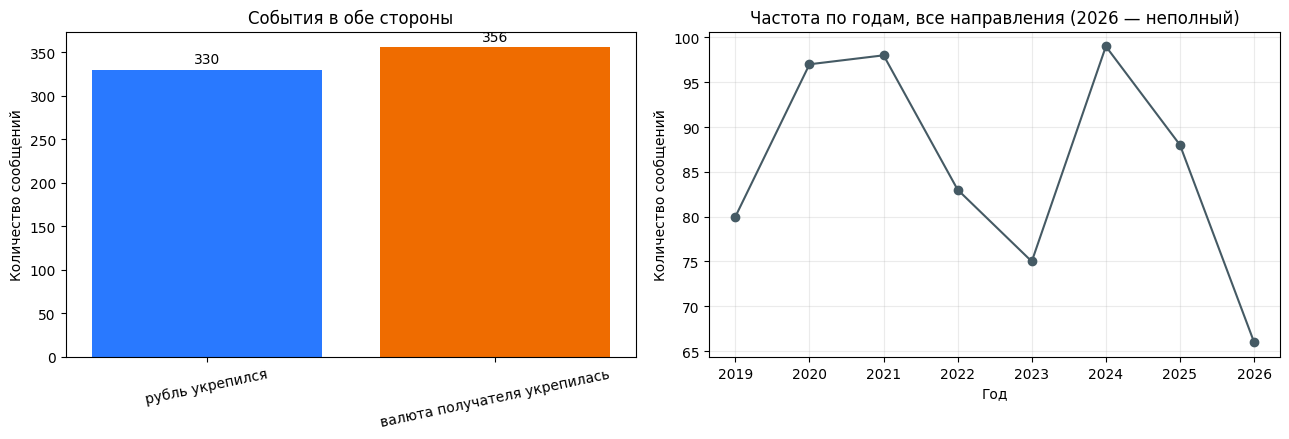

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

direction_counts = events["direction"].value_counts().reindex([
    "рубль укрепился", "валюта получателя укрепилась"
])
axes[0].bar(direction_counts.index, direction_counts.values, color=["#2979ff", "#ef6c00"])
axes[0].set_title("События в обе стороны")
axes[0].set_ylabel("Количество сообщений")
axes[0].tick_params(axis="x", rotation=12)
for i, value in enumerate(direction_counts.values):
    axes[0].text(i, value + max(direction_counts.values) * 0.02, str(value), ha="center")

year_total = by_year.sum(axis=1)
axes[1].plot(year_total.index, year_total.values, marker="o", color="#455a64")
axes[1].set_title("Частота по годам, все направления (2026 — неполный)")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Количество сообщений")
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mvp_frequency_and_direction.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Два реальных примера

Примеры выбираются не по отметке «удачный день», а как недавние события с величиной движения около медианы. Это показывает обычный вид сигнала, а не самый красивый случай.

Пунктиром отмечена дата, относительно которой измерялось движение; точкой — дата сообщения.

,дата,направление,изменение,пример сообщения
0,2025-10-02,KGS_RUB,-2.97%,С 25.09 рубль заметно укрепился сразу к нескол...


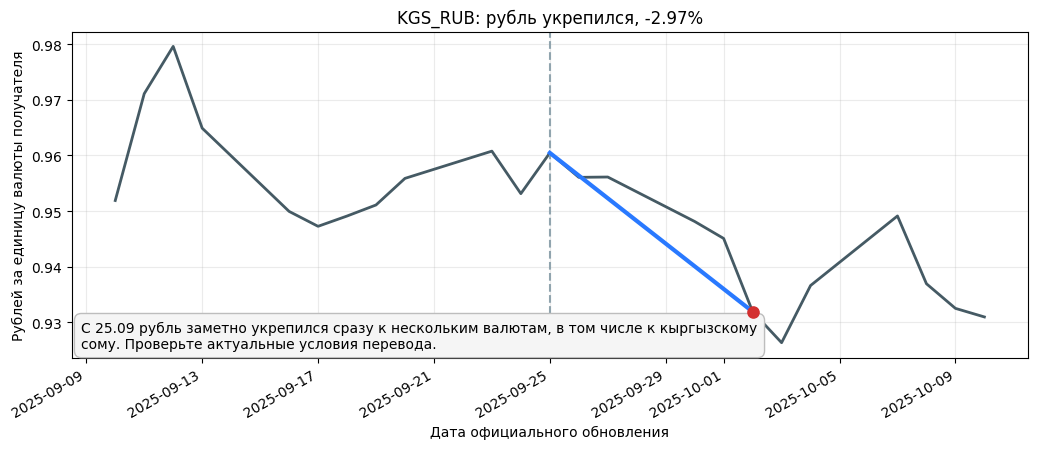

,дата,направление,изменение,пример сообщения
0,2026-08-28,TJS_RUB,+3.15%,С 21.08 рубль заметно ослаб сразу к нескольким...


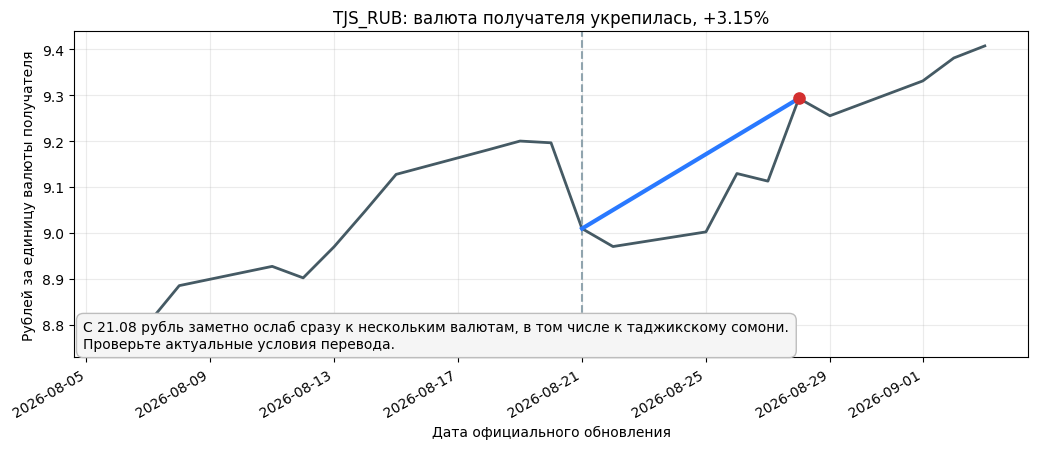

In [11]:
def representative_event(direction: str) -> pd.Series:
    subset = events[(events.direction == direction) & (events.date >= "2024-01-01")].copy()
    target = subset.movement_abs.median()
    subset["distance_to_typical"] = (subset.movement_abs - target).abs()
    return subset.sort_values(["distance_to_typical", "date"], ascending=[True, False]).iloc[0]

examples = {
    "rub_strengthened": representative_event("рубль укрепился"),
    "recipient_strengthened": representative_event("валюта получателя укрепилась"),
}

def plot_event(row: pd.Series, output_name: str):
    series = df[df.corridor.eq(row.corridor)].copy()
    event_pos = series.index.get_loc(row.name)
    window = series.iloc[max(0, event_pos - 16): min(len(series), event_pos + 7)]
    start_row = series.loc[series.date.eq(row.comparison_date)].iloc[0]

    fig, ax = plt.subplots(figsize=(10.5, 4.6))
    ax.plot(window.date, window.rate, color="#455a64", linewidth=2)
    ax.axvline(row.comparison_date, color="#90a4ae", linestyle="--", linewidth=1.5)
    ax.scatter([row.date], [row.rate], color="#d32f2f", s=65, zorder=5)
    ax.plot([row.comparison_date, row.date], [start_row.rate, row.rate], color="#2979ff", linewidth=3)
    sign = "+" if row.ret_5 > 0 else ""
    ax.set_title(f"{row.corridor}: {row.direction}, {sign}{row.ret_5:.2%}")
    ax.set_ylabel("Рублей за единицу валюты получателя")
    ax.set_xlabel("Дата официального обновления")
    ax.grid(alpha=0.25)
    ax.text(
        0.01, 0.03, textwrap.fill(row.push_example, width=90),
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="#bdbdbd"),
    )
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=160, bbox_inches="tight")
    plt.show()

for output_name, row in examples.items():
    display(pd.DataFrame({
        "дата": [row.date.date()],
        "направление": [row.corridor],
        "изменение": [f"{row.ret_5:+.2%}"],
        "пример сообщения": [row.push_example],
    }))
    plot_event(row, f"example_{output_name}.png")

## 8. Как реагировать на основной сигнал

Рабочая замена основного сигнала ниже нужна только для оценки возможного конфликта: `dist_min_10 ≤ 1%` и `favourability_percentile_20 ≥ 80%`. Она не считается фактическим решением коллеги.

Правило продуктового оркестратора:

1. Если на ту же дату есть основной сигнал, отправляем основной; дополнительный подавляем.
2. Если недельный лимит клиента уже исчерпан, ничего не отправляем.
3. Если недавно был основной сигнал, дополнительный можно отложить или подавить согласно общему перерыву между сообщениями.
4. Если клиент открыл сообщение позже, показываем текущий расчёт, а не зафиксированную в уведомлении сумму.

Оценка совпадения с рабочей заменой показывает масштаб потенциального конфликта, но окончательно его нужно пересчитать на настоящем потоке основного сигнала.

In [12]:
overlap = pd.DataFrame({
    "проверка": [
        "дополнительных событий",
        "совпали по дате с рабочей заменой основного",
        "остались бы после подавления совпадений",
    ],
    "количество": [
        len(events),
        int(events.same_day_main_proxy.sum()),
        int((~events.same_day_main_proxy).sum()),
    ],
})
display(overlap)

,проверка,количество
0,дополнительных событий,686
1,совпали по дате с рабочей заменой основного,56
2,остались бы после подавления совпадений,630


## 9. Как понять, что дополнительное уведомление работает

Исторические курсы отвечают только на вопрос «можем ли мы честно и не слишком часто находить понятные изменения?». Они не содержат открытий приложения, расчётов суммы или переводов, поэтому не доказывают клиентскую пользу.

Первый чистый эксперимент:

| Группа | Что получает |
|---|---|
| Контроль | Обычные и основные уведомления; D1 вычисляется, но не отправляется |
| Тест | Те же уведомления + D1 о необычном движении |

Клиенты случайно распределяются в группы без использования их личной истории. Правило D1 одинаково срабатывает для обеих групп на уровне направления. D2 и D3 не следует добавлять в первый эксперимент: иначе будет непонятно, какое правило дало результат.

Единица измерения — **подходящий клиент за неделю**, а не отдельный день и не отдельный пуш. В знаменатель входят клиенты направления в недели, когда D1 мог быть отправлен. Для этого в рабочей системе всё равно потребуются обезличенный идентификатор экспериментальной группы и события приложения, но не история переводов для расчёта правила.

Главный показатель:

`дополнительная недельная доля проверивших условия = доля подходящих клиентов с открытием расчёта в тесте − та же доля в контроле`

Открытие самого уведомления — ранний показатель. Полезное действие — переход на экран актуальных условий или запуск расчёта. Firebase также рекомендует задавать для эксперимента целевое событие аналитики, а не ограничиваться доставкой сообщения ([документация A/B-тестирования](https://firebase.google.com/docs/ab-testing/abtest-with-console)).

Ограничители:

- отключения и отписки от уведомлений;
- число всех уведомлений за неделю;
- реакция на следующий основной сигнал;
- доля открытий, после которых пользователь сразу ушёл, не посмотрев условия;
- переводы — важный вторичный результат, но их нельзя требовать от каждого информационного сообщения.

После проверки D1 отдельными экспериментами можно сравнить D2 и D3. D4 тестируется как вариант текста внутри D1: простой текст против текста с общим валютным контекстом.

In [13]:
experiment_metrics = pd.DataFrame([
    {
        "показатель": "Недельная доля клиентов, проверивших сумму",
        "роль": "главный",
        "как считаем": "уникальные клиенты с расчётом / подходящие клиенты",
        "признак успеха": "в тесте статистически выше контроля",
    },
    {
        "показатель": "Недельная доля открывших приложение",
        "роль": "ранний",
        "как считаем": "уникальные клиенты с открытием / подходящие клиенты",
        "признак успеха": "объясняет путь к расчёту, но не заменяет главный показатель",
    },
    {
        "показатель": "Отключение уведомлений",
        "роль": "ограничитель",
        "как считаем": "клиенты с отключением / подходящие клиенты",
        "признак успеха": "не хуже заранее заданной допустимой границы",
    },
    {
        "показатель": "Реакция на следующий основной сигнал",
        "роль": "ограничитель",
        "как считаем": "открытие или расчёт после следующего основного сигнала",
        "признак успеха": "дополнительные сообщения не снижают реакцию",
    },
])
display(experiment_metrics)

,показатель,роль,как считаем,признак успеха
0,"Недельная доля клиентов, проверивших сумму",главный,уникальные клиенты с расчётом / подходящие кли...,в тесте статистически выше контроля
1,Недельная доля открывших приложение,ранний,уникальные клиенты с открытием / подходящие кл...,"объясняет путь к расчёту, но не заменяет главн..."
2,Отключение уведомлений,ограничитель,клиенты с отключением / подходящие клиенты,не хуже заранее заданной допустимой границы
3,Реакция на следующий основной сигнал,ограничитель,открытие или расчёт после следующего основного...,дополнительные сообщения не снижают реакцию


## 10. Итоговая методика человеческим языком

1. **Каждый раз после нового официального курса считаем, насколько валюта изменилась за последние пять обновлений.**
2. **Сравниваем это движение не с будущим и не с удачными днями, а только с предыдущими 60 движениями того же направления.** Сигнал появляется, если изменение не меньше 1% и сильнее как минимум 80% недавних случаев.
3. **Проверяем, кто укрепился.** Падение показателя `RUB за валюту получателя` означает укрепление рубля; рост — укрепление валюты получателя.
4. **Смотрим общий валютный фон.** Если рубль так же движется к USD, EUR и CNY, можно сказать, что движение видно сразу по нескольким валютам. Если выделяется остаток конкретного направления, говорим только о его валюте. Причины не придумываем.
5. **Сообщаем только уже произошедший факт.** Не пишем «лучший момент», «успейте», «курс продолжит расти» или «вы получите выгоду».
6. **Отправляем не чаще одного дополнительного сообщения по направлению в неделю и не ближе четырёх дней.** Если есть основной сигнал, дополнительный подавляется.
7. **Ведём на актуальные условия.** Официальный курс нужен для обнаружения движения, но не является обещанным курсом перевода.
8. **Проверяем пользу экспериментом.** Успех — прирост недельной доли клиентов, открывших экран актуальных условий, без роста отписок и без ухудшения реакции на основной сигнал. Отметка `good` и преимущество над случайным днём здесь не являются целевыми показателями.

### Что подтверждено текущими данными

- D1 даёт 686 событий за период и срабатывает в 34,9% недель направления;
- медианное движение в событии D1 составляет 2,8%;
- стороны почти сбалансированы: в 48,1% событий укрепился рубль;
- 81,0% событий D1 объясняются широким движением рубля, 10,8% сильнее выделяют валюту получателя, остальные имеют смешанный характер;
- только 8,2% событий совпадают по дате с рабочей заменой основного сигнала;
- объединённый поток D1–D3 даёт 996 событий, или 0,51 сообщения на направление в неделю, после ограничения частоты.

### Чего эти данные не доказывают

- что клиент откроет уведомление или экран условий;
- что перевод состоится;
- что официальный ориентир совпадает с банковским курсом;
- что статистический общий или локальный компонент является экономической причиной движения.